<a href="https://colab.research.google.com/github/Ayon150/MY_THESIS_CODE/blob/main/Probably_best_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu126

!wget https://github.com/state-spaces/mamba/releases/download/v2.2.6.post3/mamba_ssm-2.2.6.post3+cu12torch2.7cxx11abiTRUE-cp312-cp312-linux_x86_64.whl
!pip install mamba_ssm-2.2.6.post3+cu12torch2.7cxx11abiTRUE-cp312-cp312-linux_x86_64.whl

Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 160.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 128.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 194.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 73.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 76.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 77.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 152.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 121.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 104.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 85.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 91.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/8

In [2]:
!pip install transformers==4.39.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 141.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.6.0
    Uninstalling huggingface_hub-1.6.0:
      Successfully uninstalled huggingface_hub-1.6.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from tqdm import tqdm
from einops import rearrange
import matplotlib.pyplot as plt
from mamba_ssm import Mamba

Saving DRIVE.zip to DRIVE.zip
Dataset extracted successfully!

Folders inside /content:
['.config', 'mamba_ssm-2.2.6.post3+cu12torch2.7cxx11abiTRUE-cp312-cp312-linux_x86_64.whl', 'DRIVE.zip', 'DRIVE', 'sample_data']

Checking dataset structure...
Training images: 20
Training masks: 20
Test images: 20
Test masks: 20

Train samples: 20
Test samples: 20

Dataloaders created successfully!


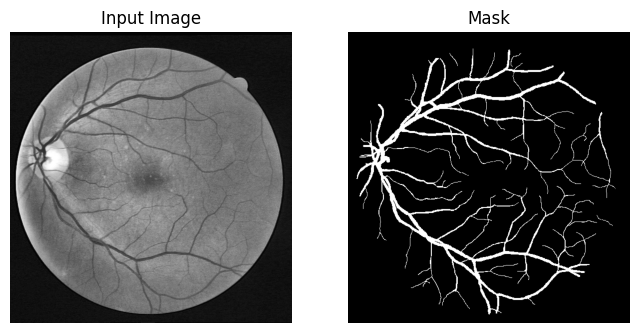

In [4]:
# ==========================================================
# UPLOAD ZIP DATASET -> UNZIP -> LOAD -> CREATE DATALOADERS
# ==========================================================

# 1️⃣ Upload ZIP dataset
from google.colab import files
uploaded = files.upload()

# Get uploaded file name
zip_name = list(uploaded.keys())[0]

# 2️⃣ Unzip dataset
import os
import zipfile

extract_path = "/content/"

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

# 3️⃣ Check extracted folders
print("\nFolders inside /content:")
print(os.listdir("/content"))

# Change this if your folder name is different
dataset_path = "/content/DRIVE"

# 4️⃣ Verify dataset structure
print("\nChecking dataset structure...")

print("Training images:", len(os.listdir(dataset_path + "/training/images")))
print("Training masks:", len(os.listdir(dataset_path + "/training/1st_manual")))
print("Test images:", len(os.listdir(dataset_path + "/test/images")))
print("Test masks:", len(os.listdir(dataset_path + "/test/1st_manual")))

# ==========================================================
# DATASET CLASS
# ==========================================================

import torch
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader

class DriveDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_paths = sorted(
            [os.path.join(image_dir,f) for f in os.listdir(image_dir)]
        )

        self.mask_paths = sorted(
            [os.path.join(mask_dir,f) for f in os.listdir(mask_dir)]
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.image_paths[idx])

        # Green channel extraction
        green = img[:,:,1]

        # CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
        green = clahe.apply(green)

        img = green.astype(np.float32)/255.0
        img = np.stack([img,img,img],axis=2)

        mask = cv2.imread(self.mask_paths[idx],0)
        mask = (mask>127).astype(np.float32)

        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img,mask


# ==========================================================
# CREATE DATASETS
# ==========================================================

train_dataset = DriveDataset(
    dataset_path + "/training/images",
    dataset_path + "/training/1st_manual"
)

test_dataset = DriveDataset(
    dataset_path + "/test/images",
    dataset_path + "/test/1st_manual"
)

print("\nTrain samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


# ==========================================================
# CREATE DATALOADERS
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1
)

print("\nDataloaders created successfully!")


# ==========================================================
# VISUALIZE ONE SAMPLE
# ==========================================================

import matplotlib.pyplot as plt

img, mask = train_dataset[0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [ ]:
# ==========================================================
# IMPORTS
# ==========================================================
import os, cv2, numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from tqdm import tqdm
from einops import rearrange
import albumentations as A
from mamba_ssm import Mamba
from torch.utils.data import Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ==========================================================
# AUGMENTATION
# ==========================================================

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(scale=(0.9,1.1), rotate=(-15,15), p=0.5),
    A.GaussNoise(p=0.2),
    A.RandomBrightnessContrast(p=0.3)
])

# ==========================================================
# DATASET
# ==========================================================

class DriveDataset(Dataset):

    def __init__(self, image_paths, mask_paths, fov_paths=None, transform=None,
                 patch_only=False, deterministic=False):
        self.deterministic = deterministic
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.fov_paths = fov_paths

        self.patch_only = patch_only

        self.patch_size = 128
        self.patches_per_image = 16

        self.transform = transform

    def __len__(self):
        return 4000 if self.patch_only else len(self.image_paths)



    def __getitem__(self, idx):

        # ------------------------------------------------
        # Determine image index
        # ------------------------------------------------
        if self.patch_only:
            img_id = np.random.randint(len(self.image_paths))
        else:
            img_id = idx

        # ------------------------------------------------
        # Load image and mask
        # ------------------------------------------------
        img = cv2.imread(self.image_paths[img_id])
        img = cv2.resize(img,(512,512))

        mask = cv2.imread(self.mask_paths[img_id],0)
        mask = cv2.resize(mask,(512,512))
        mask = (mask > 127).astype(np.float32)

        # ------------------------------------------------
        # GREEN CHANNEL
        # ------------------------------------------------
        green = img[:,:,1]

        # ------------------------------------------------
        # PATCH TRAINING
        # ------------------------------------------------
        # ------------------------------------------------
        # Create 128x128 patches using einops
        # ------------------------------------------------



        # if self.patch_only:

        #   green_patches = rearrange(
        #       green,
        #       '(h ph) (w pw) -> (h w) ph pw',
        #       ph=128,
        #       pw=128
        #   )

        #   mask_patches = rearrange(
        #       mask,
        #       '(h ph) (w pw) -> (h w) ph pw',
        #       ph=128,
        #       pw=128
        #   )

        #   green = green_patches[patch_id]
        #   mask  = mask_patches[patch_id]

        if self.patch_only:

              img_id = np.random.randint(len(self.image_paths))
              H, W = green.shape
              ps = self.patch_size

              # vessel-aware sampling
              if np.random.rand() < 0.5:
                  vessel_pixels = np.argwhere(mask > 0)
                  if len(vessel_pixels) > 0:
                      y, x = vessel_pixels[np.random.randint(len(vessel_pixels))]
                  else:
                      y, x = np.random.randint(H), np.random.randint(W)
              else:
                  y, x = np.random.randint(H), np.random.randint(W)

              y1 = np.clip(y - ps//2, 0, H - ps)
              x1 = np.clip(x - ps//2, 0, W - ps)

              green = green[y1:y1+ps, x1:x1+ps]
              mask  = mask[y1:y1+ps, x1:x1+ps]



        # ------------------------------------------------
        # CLAHE
        # ------------------------------------------------
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        green = clahe.apply(green)

        # ------------------------------------------------
        # Gamma correction
        # ------------------------------------------------
        gamma = 1.2
        invGamma = 1.0 / gamma
        table = np.array([(i / 255.0) ** invGamma * 255
                          for i in np.arange(256)]).astype("uint8")

        green = cv2.LUT(green, table)

        # ------------------------------------------------
        # Sharpening
        # ------------------------------------------------
        # kernel = np.array([[0,-1,0],
        #                   [-1,5,-1],
        #                   [0,-1,0]])

        # green = cv2.filter2D(green,-1,kernel)

        # ------------------------------------------------
        # Top-hat vessel enhancement
        # ------------------------------------------------
        #kernel_tophat = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15))
        #green = cv2.morphologyEx(green, cv2.MORPH_TOPHAT, kernel_tophat)

        # ------------------------------------------------
        # Normalize image
        # ------------------------------------------------
        img = green.astype(np.float32) / 255.0
        img = np.stack([img,img,img], axis=2)

        # ------------------------------------------------
        # AUGMENTATION
        # ------------------------------------------------
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]

        # ------------------------------------------------
        # Convert to tensor
        # ------------------------------------------------
        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        # ------------------------------------------------
        # FOV (for test dataset)
        # ------------------------------------------------
        if self.fov_paths:

            fov = cv2.imread(self.fov_paths[img_id],0)
            fov = cv2.resize(fov,(512,512))
            fov = (fov > 127).astype(np.float32)

            fov = torch.tensor(fov).unsqueeze(0).float()

            return img, mask, fov

        return img, mask

# ==========================================================
# CONV BLOCK(skip connection added)
# ==========================================================

class ConvBlock(nn.Module):

    def __init__(self,in_c,out_c):

        super().__init__()

        self.conv1 = nn.Conv2d(in_c,out_c,3,padding=1)
        self.bn1 = nn.GroupNorm(8,out_c)

        self.conv2 = nn.Conv2d(out_c,out_c,3,padding=1)
        self.bn2 = nn.GroupNorm(8,out_c)

        self.CELU = nn.CELU(inplace=True)

        self.shortcut = nn.Identity()

        if in_c != out_c:
            self.shortcut = nn.Conv2d(in_c,out_c,1)

    def forward(self,x):

        residual = self.shortcut(x)

        x = self.CELU(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        x = x + residual

        return self.CELU(x)

# ==========================================================
# ATTENTION GATE
# ==========================================================

class AttentionGate(nn.Module):

    def __init__(self,Fg,Fl,Fint):

        super().__init__()

        self.Wg = nn.Conv2d(Fg,Fint,1)
        self.Wx = nn.Conv2d(Fl,Fint,1)
        self.psi = nn.Sequential(
            nn.Conv2d(Fint,1,1),
            nn.Sigmoid()
        )

    def forward(self,g,x):

        g1 = self.Wg(g)
        x1 = self.Wx(x)

        if g1.shape != x1.shape:
            g1 = F.interpolate(g1,size=x1.shape[2:],mode="bilinear")

        psi = torch.relu(g1+x1)
        psi = self.psi(psi)

        return x*psi

# ==========================================================
# MAMBA BLOCK
# ==========================================================

class VisionMambaBlock(nn.Module):

    def __init__(self,dim):

        super().__init__()

        self.norm = nn.LayerNorm(dim)

        self.mamba = Mamba(
            d_model=dim,
            d_state=16,
            d_conv=4,
            expand=2
        )

    def forward(self,x):

        B,C,H,W = x.shape
        res = x

        x = rearrange(x,"b c h w -> b (h w) c")

        x = self.norm(x)
        x = self.mamba(x)

        x = rearrange(x,"b (h w) c -> b c h w",h=H,w=W)

        return x + res

# ==========================================================
# MODEL
# ==========================================================

class MambaUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.enc1 = ConvBlock(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.mamba_enc2 = VisionMambaBlock(128)

        self.enc3 = ConvBlock(128,256)
        self.pool3 = nn.MaxPool2d(2)

        # MULTIPLE MAMBA BLOCKS
        self.mamba1 = VisionMambaBlock(256)

        self.bottleneck = ConvBlock(256,512)
        self.dropout = nn.Dropout2d(0.2)

        self.mamba2 = VisionMambaBlock(512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionGate(256,256,128)
        self.dec3 = ConvBlock(512,256)

        self.mamba3 = VisionMambaBlock(256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionGate(128,128,64)
        self.dec2 = ConvBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionGate(64,64,32)
        self.dec1 = ConvBlock(128,64)

        self.gc3 = nn.Conv2d(512, 256, 1)
        self.gc2 = nn.Conv2d(512, 128, 1)
        self.gc1 = nn.Conv2d(512, 64, 1)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):

        e1 = self.enc1(x)

        e2 = self.enc2(self.pool1(e1))
        e2 = self.mamba_enc2(e2)

        e3 = self.enc3(self.pool2(e2))
        e3 = self.mamba1(e3)

        b = self.bottleneck(self.pool3(e3))
        b = self.dropout(b)
        b = self.mamba2(b)

        gc = F.adaptive_avg_pool2d(b, 1) #new

        d3 = self.up3(b)
        e3 = self.att3(d3,e3)
        d3 = self.dec3(torch.cat([d3,e3],1))

        d3 = d3 + self.gc3(gc) #new

        d3 = self.mamba3(d3)

        d2 = self.up2(d3)
        e2 = self.att2(d2,e2)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d2 = d2 + self.gc2(gc) #new

        d1 = self.up1(d2)
        e1 = self.att1(d1,e1)
        d1 = self.dec1(torch.cat([d1,e1],1))

        d1 = d1 + self.gc1(gc) #new

        out = self.final(d1)

        return out

# ==========================================================
# LOSS
# ==========================================================

class DiceBCELoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self,pred,target):

        bce = self.bce(pred,target)

        pred = torch.sigmoid(pred)

        smooth = 1

        pred = pred.view(pred.size(0),-1)
        target = target.view(target.size(0),-1)

        intersection = (pred*target).sum(1)

        dice = (2*intersection + smooth) / \
               (pred.sum(1) + target.sum(1) + smooth)

        dice = dice.mean()

        return bce + (1-dice)

# ==========================================================
# DATA LOADING
# ==========================================================

# ==========================================================
# DATA LOADING
# ==========================================================

dataset_path = "/content/DRIVE"

train_img_dir = dataset_path + "/training/images"
train_mask_dir = dataset_path + "/training/1st_manual"

image_paths = sorted([os.path.join(train_img_dir,f) for f in os.listdir(train_img_dir)])
mask_paths = sorted([os.path.join(train_mask_dir,f) for f in os.listdir(train_mask_dir)])
# split by image
train_img = image_paths[:16]
train_mask = mask_paths[:16]

val_img = image_paths[16:]
val_mask = mask_paths[16:]

# -----------------------------
# TRAIN DATASET (patch training)
# -----------------------------
train_dataset = DriveDataset(
    train_img,
    train_mask,
    transform=train_transform,
    patch_only=True
)

# Only first 16 images used for training
#train_dataset = Subset(train_dataset, list(range(16)))

# -----------------------------
# VALIDATION DATASET (full images)
# -----------------------------
val_dataset = DriveDataset(
    val_img,
    val_mask,
    transform=None,
    patch_only=False,
    #deterministic=True
)

# -----------------------------
# TEST PATHS
# -----------------------------
test_img_dir = dataset_path + "/test/images"
test_mask_dir = dataset_path + "/test/1st_manual"
test_fov_dir = dataset_path + "/test/mask"

test_images = sorted([os.path.join(test_img_dir,f) for f in os.listdir(test_img_dir)])
test_masks = sorted([os.path.join(test_mask_dir,f) for f in os.listdir(test_mask_dir)])
test_fov = sorted([os.path.join(test_fov_dir,f) for f in os.listdir(test_fov_dir)])

# -----------------------------
# TEST DATASET
# -----------------------------
test_dataset = DriveDataset(
    test_images,
    test_masks,
    test_fov
)

# -----------------------------
# DATALOADERS
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=12,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(val_dataset,batch_size=1)
test_loader = DataLoader(test_dataset,batch_size=1)

print("Train samples:",len(train_dataset))
print("Val samples:",len(val_dataset))

# ==========================================================
# MODEL SETUP
# ==========================================================
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

model = MambaUNet().to(device)

criterion = DiceBCELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

epochs = 80

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

best_val_loss = 999

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

import torch, gc
gc.collect()
torch.cuda.empty_cache()

# ==========================================================
# TRAINING
# ==========================================================

#epochs = 200

for epoch in range(epochs):

    model.train()

    train_loss=0

    for imgs,masks in tqdm(train_loader):

        imgs,masks = imgs.to(device),masks.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs,masks)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

        optimizer.step()

        train_loss += loss.item()

    # VALIDATION
    # model.eval()
    # val_loss=0

    # with torch.no_grad():

    #     for imgs,masks in val_loader:

    #         imgs,masks = imgs.to(device),masks.to(device)

    #         outputs = model(imgs)

    #         loss = criterion(outputs,masks)

    #         val_loss += loss.item()
    # model.eval()
    # val_loss = 0

    # with torch.no_grad():

    #     full_pred = np.zeros((512,512))
    #     count_map = np.zeros((512,512))

    #     for i, (imgs, masks) in enumerate(val_loader):

    #         imgs = imgs.to(device)

    #         logits = model(imgs)
    #         probs = torch.sigmoid(logits).cpu().numpy()[0,0]

    #         # reconstruct position
    #         ps = 128
    #         patches_per_row = 512 // ps

    #         y = (i // patches_per_row) * ps
    #         x = (i % patches_per_row) * ps

    #         full_pred[y:y+ps, x:x+ps] += probs
    #         count_map[y:y+ps, x:x+ps] += 1

    #     full_pred /= count_map

    #     # compute loss on full image
    #     gt = cv2.imread(val_mask[0],0)
    #     gt = cv2.resize(gt,(512,512))
    #     gt = (gt > 127).astype(np.float32)

    #     pred_tensor = torch.tensor(full_pred).unsqueeze(0).unsqueeze(0).to(device)
    #     gt_tensor = torch.tensor(gt).unsqueeze(0).unsqueeze(0).to(device)

    #     val_loss = criterion(pred_tensor, gt_tensor).item()
    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for imgs, masks in val_loader:

            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

    train_loss/=len(train_loader)
    val_loss/=len(val_loader)

    scheduler.step()
    torch.cuda.empty_cache()

    print(f"Epoch {epoch+1} Train Loss {train_loss:.4f} Val Loss {val_loss:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(),"best_model.pth")

        print("Best model saved")

# ==========================================================
# EVALUATION
# ==========================================================

model.load_state_dict(torch.load("best_model.pth"))

def evaluate(model, loader):

    model.eval()

    thresholds = np.arange(0.15,0.7,0.02)

    results = []

    with torch.no_grad():

        for th in thresholds:

            dice_all=[]
            auc_all=[]
            precision_all=[]
            recall_all=[]
            f1_all=[]

            for imgs,masks,fov in loader:

                imgs = imgs.to(device)

                # -----------------------------
                # TEST TIME AUGMENTATION (TTA)
                # -----------------------------

                logits1 = model(imgs)

                imgs_flip = torch.flip(imgs,[3])
                logits2 = model(imgs_flip)
                logits2 = torch.flip(logits2,[3])

                imgs_flip2 = torch.flip(imgs,[2])
                logits3 = model(imgs_flip2)
                logits3 = torch.flip(logits3,[2])

                logits = (logits1 + logits2 + logits3) / 3.0

                probs = torch.sigmoid(logits).cpu().numpy()[0,0]

                preds = (probs>th).astype(np.float32)

                masks = masks.numpy()[0,0]
                fov = fov.numpy()[0,0]

                # -----------------------------
                # FOV MASKING
                # -----------------------------

                preds = preds*fov
                masks = masks*fov

                # -----------------------------
                # MORPHOLOGICAL CLEANING
                # -----------------------------

                kernel = np.ones((3,3),np.uint8)

                preds = cv2.morphologyEx(preds, cv2.MORPH_CLOSE, kernel)

                # -----------------------------
                # METRICS
                # -----------------------------

                smooth=1

                dice = (2*(preds*masks).sum()+smooth)/(preds.sum()+masks.sum()+smooth)

                valid = fov.flatten() > 0

                auc = roc_auc_score(
                    masks.flatten()[valid],
                    probs.flatten()[valid]
                )

                precision = precision_score(masks.flatten(),preds.flatten(),zero_division=0)
                recall = recall_score(masks.flatten(),preds.flatten(),zero_division=0)
                f1 = f1_score(masks.flatten(),preds.flatten(),zero_division=0)

                dice_all.append(dice)
                auc_all.append(auc)
                precision_all.append(precision)
                recall_all.append(recall)
                f1_all.append(f1)

            results.append([
                th,
                np.mean(dice_all),
                np.mean(auc_all),
                np.mean(precision_all),
                np.mean(recall_all),
                np.mean(f1_all)
            ])

    df = pd.DataFrame(results, columns=[
        "Threshold",
        "Dice",
        "AUC",
        "Precision",
        "Sensitivity",
        "F1"
    ])

    # Save CSV
    df.to_csv("drive_results.csv", index=False)

    best = df.iloc[df["Dice"].idxmax()]

    print("\nBEST TEST RESULT")
    print(best)

    print("\nResults saved to drive_results.csv")

    return df

results = evaluate(model, test_loader)

Device: cuda
Train samples: 4000
Val samples: 4
Train samples: 4000
Val samples: 4


100%|██████████| 334/334 [01:47<00:00,  3.11it/s]


Epoch 1 Train Loss 0.6530 Val Loss 0.3947
Best model saved


100%|██████████| 334/334 [01:46<00:00,  3.14it/s]


Epoch 2 Train Loss 0.4922 Val Loss 0.3680
Best model saved


...

100%|██████████| 334/334 [01:46<00:00,  3.15it/s]


Epoch 53 Train Loss 0.3469 Val Loss 0.3359


100%|██████████| 334/334 [01:46<00:00,  3.15it/s]


Epoch 54 Train Loss 0.3428 Val Loss 0.3283


 75%|███████▍  | 250/334 [01:19<00:26,  3.17it/s]

In [11]:
def evaluate(model, loader):

    model.eval()

    thresholds = np.arange(0.15,0.7,0.02)

    results = []

    with torch.no_grad():

        for th in thresholds:

            dice_all=[]
            auc_all=[]
            precision_all=[]
            recall_all=[]
            f1_all=[]

            for imgs,masks,fov in loader:

                imgs = imgs.to(device)

                # -----------------------------
                # TEST TIME AUGMENTATION (TTA)
                # -----------------------------

                logits1 = model(imgs)

                imgs_flip = torch.flip(imgs,[3])
                logits2 = model(imgs_flip)
                logits2 = torch.flip(logits2,[3])

                imgs_flip2 = torch.flip(imgs,[2])
                logits3 = model(imgs_flip2)
                logits3 = torch.flip(logits3,[2])

                logits = (logits1 + logits2 + logits3) / 3.0

                probs = torch.sigmoid(logits).cpu().numpy()[0,0]

                preds = (probs>th).astype(np.float32)

                masks = masks.numpy()[0,0]
                fov = fov.numpy()[0,0]

                # -----------------------------
                # FOV MASKING
                # -----------------------------

                preds = preds*fov
                masks = masks*fov

                # -----------------------------
                # MORPHOLOGICAL CLEANING
                # -----------------------------

                kernel = np.ones((3,3),np.uint8)

                preds = cv2.morphologyEx(preds, cv2.MORPH_CLOSE, kernel)

                # -----------------------------
                # METRICS
                # -----------------------------

                smooth=1

                dice = (2*(preds*masks).sum()+smooth)/(preds.sum()+masks.sum()+smooth)

                valid = fov.flatten() > 0

                auc = roc_auc_score(
                    masks.flatten()[valid],
                    probs.flatten()[valid]
                )

                precision = precision_score(masks.flatten(),preds.flatten(),zero_division=0)
                recall = recall_score(masks.flatten(),preds.flatten(),zero_division=0)
                f1 = f1_score(masks.flatten(),preds.flatten(),zero_division=0)

                dice_all.append(dice)
                auc_all.append(auc)
                precision_all.append(precision)
                recall_all.append(recall)
                f1_all.append(f1)

            results.append([
                th,
                np.mean(dice_all),
                np.mean(auc_all),
                np.mean(precision_all),
                np.mean(recall_all),
                np.mean(f1_all)
            ])

    df = pd.DataFrame(results, columns=[
        "Threshold",
        "Dice",
        "AUC",
        "Precision",
        "Sensitivity",
        "F1"
    ])

    # Save CSV
    df.to_csv("drive_results.csv", index=False)

    best = df.iloc[df["Dice"].idxmax()]

    print("\nBEST TEST RESULT")
    print(best)

    print("\nResults saved to drive_results.csv")

    return df

results = evaluate(model, test_loader)


BEST TEST RESULT
Threshold      0.610000
Dice           0.815528
AUC            0.979065
Precision      0.805338
Sensitivity    0.830007
F1             0.815524
Name: 23, dtype: float64

Results saved to drive_results.csv
